In [1]:
import numpy as np
import load_problem as ld
import minimize as mn
import connect as ct
import symmetrize as sy
import indices as ind
import spectral as sp
import eigen_solver as es
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import normalized_mutual_info_score
%matplotlib inline

In [2]:
def subspace_clustering(problem, ground_truth, set_gamma=0.001,
                        set_K=0,
                        printer=False,
                        plotter=False,
                        save_figure=False):
    """perform subspace clustering
    keyword arguments:
        problem: to cluster
        ground_truth: of the problem
        set_gamma: convex factor
        set_K: sets the number of K's <- beeter desc
        printer: print out statments for debugging default=False
        plotter: plot the problem default=False
        save_figure : plots the mutual connections 
    returns:
        normalized mutual information score
    """
    S, gt, k = ld.load_problem(problem, ground_truth, printer, plotter)
            
    # begin subspace clustering
    
    A_min = mn.minimize(S, set_gamma, printer)
    A_ind = ind.indices(A_min, set_K, printer)
    A = sy.symmetrize(A_ind, printer)
    
    # perform spectral clustering
    
    L = sp.laplacian(A, printer, plotter)
    
    X, Y = es.eigen_solver(L, k, printer, plotter)
    
    # perform kmeans
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=20).fit(Y)
          
    # calculate the normalized mutual information score
    nmi = normalized_mutual_info_score(gt, kmeans.labels_)
    print(problem, 'gamma:', round(set_gamma, 3), 'normalized mutual information score:', round(nmi, 3), '\n')
    
    if plotter:
        if S.shape[1] == 2:           
            prob_type = 'subspace'
            prob_title = str(problem)
            ct.connect(S, gt, L, kmeans.labels_, nmi, prob_type, prob_title, printer, save_figure, sigma=0, gamma=set_gamma)

In [3]:
set_K = 0
gamma = np.linspace(0.1,1,100)
printer = False
plotter = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/01_simple_two_and_two.tp',
                        'toy_problems/01_simple_two_and_two_ground_truth.tp',
                        i, set_K, printer, plotter,save_figure)

toy_problems/01_simple_two_and_two.tp gamma: 0.1 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.109 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.118 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.127 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.136 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.145 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.155 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.164 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.173 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.182 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamm

toy_problems/01_simple_two_and_two.tp gamma: 0.918 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.927 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.936 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.945 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.955 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.964 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.973 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.982 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 0.991 normalized mutual information score: 0.344 

toy_problems/01_simple_two_and_two.tp gamma: 1.0 normalized mutual information score: 0.344 



problem:
[[1. 1.]
 [1. 2.]
 [9. 8.]
 [9. 9.]] 

problem size: 4 x 2 

len ground truth: 4 

ground truth:
[[0]
 [0]
 [1]
 [1]] 

number of clusters n: 2 



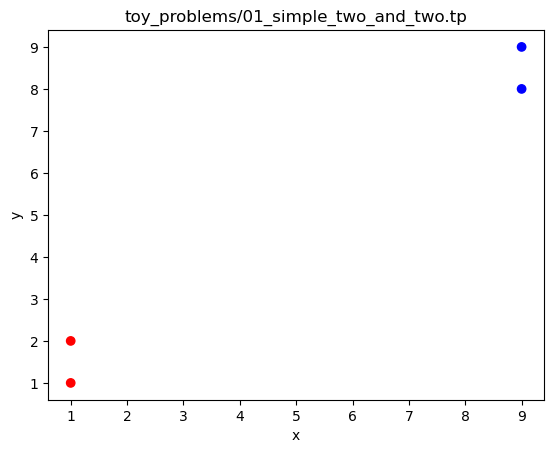

S_transpose =
[[1. 1. 9. 9.]
 [1. 2. 8. 9.]] 

shape of S_transpose = (2, 4) 

create A =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 


************************************************
            Solve for coefficents
b =
 [1. 1.]
A =
[[5.73206211e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.60700569e-12 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.07551038e-11 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.11111111e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00]] 

b =
 [1. 2.]
A =
[[5.73206211e-16 9.32073145e-12 0.00000000e+00 0.00000000e+00]
 [4.60700569e-12 2.99845215e-15 0.00000000e+00 0.00000000e+00]
 [1.07551038e-11 1.62886075e-11 0.00000000e+00 0.00000000e+00]
 [1.11111111e-01 1.51591574e-01 0.00000000e+00 0.00000000e+00]] 

b =
 [9. 8.]
A =
[[ 5.73206211e-16  9.32073145e-12  8.28848935e-12  0.00000000e+00]
 [ 4.60700569e-12  2.99845215e-15 -1.69068001e-11  0.00000000e+00]
 [ 1.07551038e-11  1.62886075e-11 -9.12737343e-16  0.00000000e+00]
 

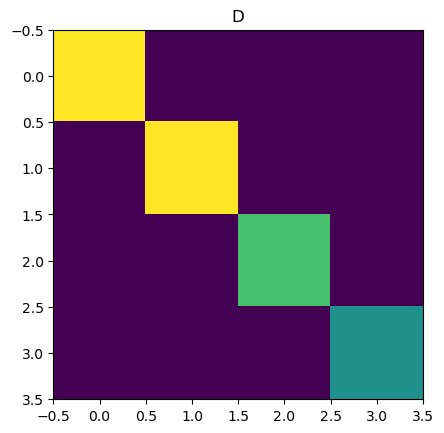

L matrix, L:
[[0.00000000e+00 1.02948866e-10 7.47513283e-11 5.00000000e-01]
 [1.02948866e-10 0.00000000e+00 8.88425339e-11 5.00000000e-01]
 [7.47513283e-11 8.88425339e-11 0.00000000e+00 7.07106781e-01]
 [5.00000000e-01 5.00000000e-01 7.07106781e-01 0.00000000e+00]] 



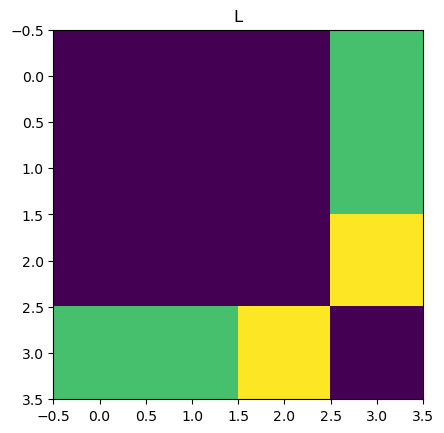

end normalized symitric laplacian 

eigenvalues:
[-1.00000000e+00 -1.04190396e-10 -6.29625365e-11  1.00000000e+00] 

eigenvectors:
[[ 3.53553391e-01 -6.09614959e-01 -6.15117551e-01 -3.53553391e-01]
 [ 3.53553391e-01  7.83143375e-01 -3.69711312e-01 -3.53553391e-01]
 [ 5.00000000e-01 -1.22703119e-01  6.96379167e-01 -5.00000000e-01]
 [-7.07106781e-01 -1.58709650e-11  4.94708774e-11 -7.07106781e-01]] 



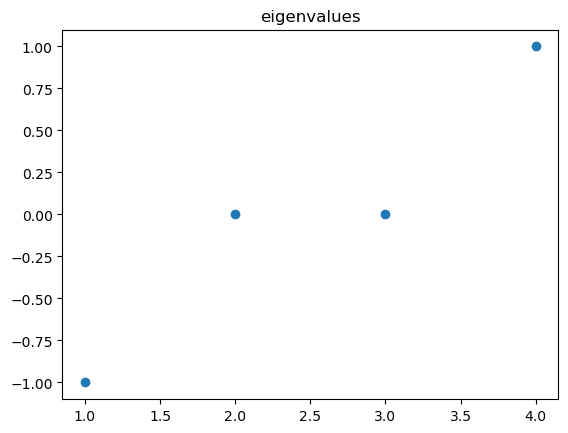

top k egienvectors:
[-1, -2] 

top k egienvectors stacked in columns, X:
[[-3.53553391e-01 -6.15117551e-01]
 [-3.53553391e-01 -3.69711312e-01]
 [-5.00000000e-01  6.96379167e-01]
 [-7.07106781e-01  4.94708774e-11]] 

X squared:
[[1.25000000e-01 3.78369601e-01]
 [1.25000000e-01 1.36686454e-01]
 [2.50000000e-01 4.84943945e-01]
 [5.00000000e-01 2.44736771e-21]] 

X squared row sum:
[[0.5033696 ]
 [0.26168645]
 [0.73494394]
 [0.5       ]] 

[[0.70948545]
 [0.51155298]
 [0.85728872]
 [0.70710678]] 

renormalized matrix, Y:
[[-4.98323668e-01 -8.66991074e-01]
 [-6.91137385e-01 -7.22723402e-01]
 [-5.83234084e-01  8.12304132e-01]
 [-1.00000000e+00  6.99623858e-11]] 

[[-4.98323668e-01 -1.20245130e+00]
 [-4.98323668e-01 -7.22723402e-01]
 [-7.04736089e-01  1.36130409e+00]
 [-9.96647335e-01  9.67072406e-11]] 



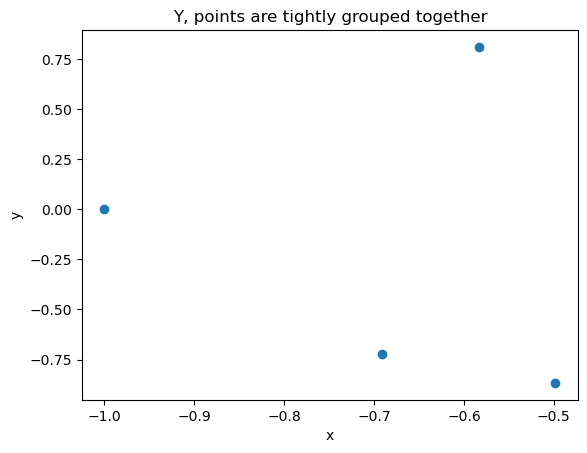

toy_problems/01_simple_two_and_two.tp gamma: 0.3 normalized mutual information score: 1.0 


labels to be checked:
[1 1 0 0] 

labels returned:
[0 0 1 1] 



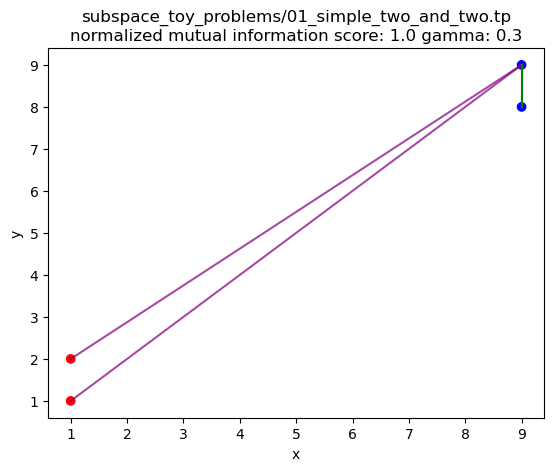

In [4]:
set_K = 0
gamma = 0.3
printer = True
plotter = True
save_figure = True
subspace_clustering('toy_problems/01_simple_two_and_two.tp',
                    'toy_problems/01_simple_two_and_two_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [5]:
set_K = 0
gamma = np.linspace(0.001,0.1,200)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/02_simple_four_and_four.tp',
                        'toy_problems/02_simple_four_and_four_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

toy_problems/02_simple_four_and_four.tp gamma: 0.001 normalized mutual information score: 0.179 

toy_problems/02_simple_four_and_four.tp gamma: 0.001 normalized mutual information score: 0.179 

toy_problems/02_simple_four_and_four.tp gamma: 0.002 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.002 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.003 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.003 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.004 normalized mutual information score: 0.179 

toy_problems/02_simple_four_and_four.tp gamma: 0.004 normalized mutual information score: 0.179 

toy_problems/02_simple_four_and_four.tp gamma: 0.005 normalized mutual information score: 0.179 

toy_problems/02_simple_four_and_four.tp gamma: 0.005 normalized mutual information score: 0.179 

toy_problems/02_simp

toy_problems/02_simple_four_and_four.tp gamma: 0.043 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.044 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.044 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.045 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.045 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.046 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.046 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.047 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.047 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.048 normalized mutual information score: 0.344 

toy_problems/02_simp

toy_problems/02_simple_four_and_four.tp gamma: 0.088 normalized mutual information score: 0.0 

toy_problems/02_simple_four_and_four.tp gamma: 0.088 normalized mutual information score: 0.0 

toy_problems/02_simple_four_and_four.tp gamma: 0.089 normalized mutual information score: 0.0 

toy_problems/02_simple_four_and_four.tp gamma: 0.089 normalized mutual information score: 0.0 

toy_problems/02_simple_four_and_four.tp gamma: 0.09 normalized mutual information score: 0.0 

toy_problems/02_simple_four_and_four.tp gamma: 0.09 normalized mutual information score: 0.344 

toy_problems/02_simple_four_and_four.tp gamma: 0.091 normalized mutual information score: 0.05 

toy_problems/02_simple_four_and_four.tp gamma: 0.091 normalized mutual information score: 0.05 

toy_problems/02_simple_four_and_four.tp gamma: 0.092 normalized mutual information score: 0.05 

toy_problems/02_simple_four_and_four.tp gamma: 0.092 normalized mutual information score: 0.05 

toy_problems/02_simple_four_and_four

problem:
[[1. 1.]
 [1. 2.]
 [2. 1.]
 [2. 2.]
 [8. 8.]
 [8. 9.]
 [9. 8.]
 [9. 9.]] 

problem size: 8 x 2 

len ground truth: 8 

ground truth:
[[0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]] 

number of clusters n: 2 



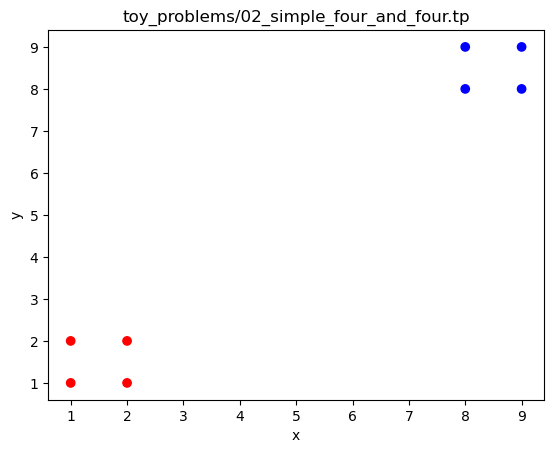

S_transpose =
[[1. 1. 2. 2. 8. 8. 9. 9.]
 [1. 2. 1. 2. 8. 9. 8. 9.]] 

shape of S_transpose = (2, 8) 

create A =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]] 


************************************************
            Solve for coefficents
b =
 [1. 1.]
A =
[[2.75530201e-15 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.71902338e-11 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.71901995e-11 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.32216703e-11 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.90752210e-11 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.

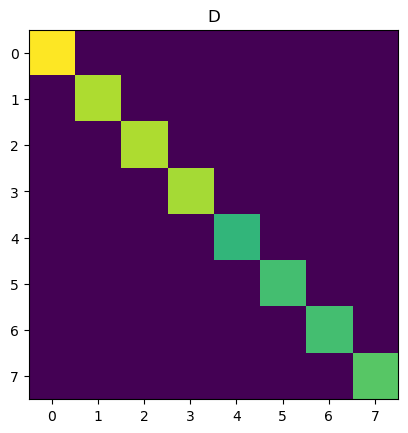

L matrix, L:
[[0.         0.09253272 0.09262423 0.07383872 0.16629741 0.1317359
  0.13174431 0.05572852]
 [0.09253272 0.         0.22266565 0.12248605 0.15334635 0.0832298
  0.14411633 0.06917042]
 [0.09262423 0.22266565 0.         0.12263413 0.15338182 0.14410371
  0.08305271 0.06889417]
 [0.07383872 0.12248605 0.12263413 0.         0.15838253 0.14144875
  0.14145736 0.11660618]
 [0.16629741 0.15334635 0.15338182 0.15838253 0.         0.18470234
  0.18471384 0.21638069]
 [0.1317359  0.0832298  0.14410371 0.14144875 0.18470234 0.
  0.19273593 0.23608108]
 [0.13174431 0.14411633 0.08305271 0.14145736 0.18471384 0.19273593
  0.         0.23609688]
 [0.05572852 0.06917042 0.06889417 0.11660618 0.21638069 0.23608108
  0.23609688 0.        ]] 



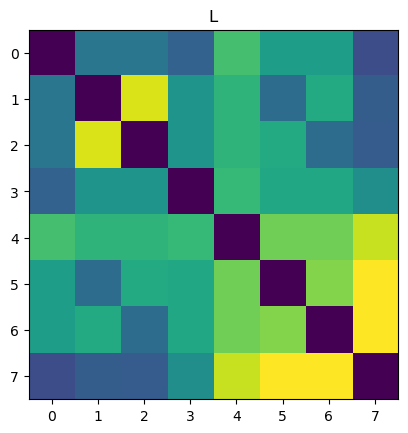

end normalized symitric laplacian 

eigenvalues:
[-0.29774854 -0.27047935 -0.19376988 -0.14492265 -0.11974752 -0.05351283
  0.08018077  1.        ] 

eigenvectors:
[[-3.13318882e-01  1.05615326e-03  1.16376141e-01 -9.59206082e-04
  -1.73265131e-01  8.79495889e-01 -9.27329332e-02  2.75957633e-01]
 [-9.42076191e-02  5.56385587e-01  6.57609726e-02 -4.35922419e-01
   2.44760777e-01 -1.52025001e-01 -5.52741703e-01  3.14108759e-01]
 [-9.66978532e-02 -5.56434917e-01  6.54049036e-02  4.36779484e-01
   2.40944167e-01 -1.51388059e-01 -5.53520063e-01  3.14036133e-01]
 [-1.15311853e-01  9.85240699e-04  6.12635604e-02 -2.68094668e-03
  -8.74596826e-01 -3.30465697e-01 -8.52554483e-02  3.18663016e-01]
 [ 4.18655946e-01 -5.54275414e-04 -7.95289097e-01  9.90516812e-05
  -8.65250499e-03  1.24743444e-01  3.33145390e-02  4.18923004e-01]
 [ 3.35187312e-01  4.35352544e-01  3.92322563e-01  5.56977020e-01
   1.03393895e-01 -8.24487485e-03  2.60534409e-01  3.94132946e-01]
 [ 3.33683970e-01 -4.37355680e-01  3.9

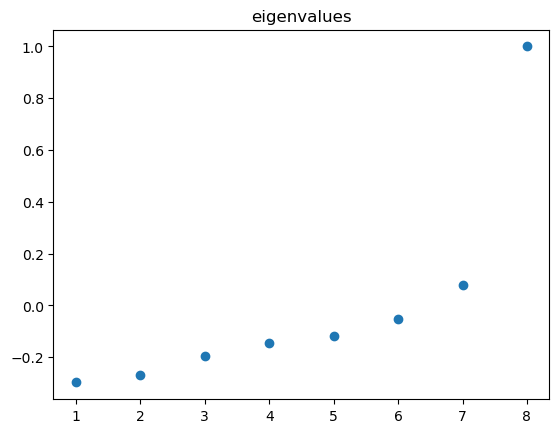

top k egienvectors:
[-1, -2] 

top k egienvectors stacked in columns, X:
[[ 0.27595763 -0.09273293]
 [ 0.31410876 -0.5527417 ]
 [ 0.31403613 -0.55352006]
 [ 0.31866302 -0.08525545]
 [ 0.418923    0.03331454]
 [ 0.39413295  0.26053441]
 [ 0.39410657  0.26106555]
 [ 0.37264059  0.48485153]] 

X squared:
[[0.07615262 0.0085994 ]
 [0.09866431 0.30552339]
 [0.09861869 0.30638446]
 [0.10154612 0.00726849]
 [0.17549648 0.00110986]
 [0.15534078 0.06787818]
 [0.15531999 0.06815522]
 [0.13886101 0.235081  ]] 

X squared row sum:
[[0.08475201]
 [0.4041877 ]
 [0.40500315]
 [0.10881461]
 [0.17660634]
 [0.22321896]
 [0.22347521]
 [0.37394202]] 

[[0.29112199]
 [0.63575758]
 [0.63639858]
 [0.32987059]
 [0.42024557]
 [0.47246054]
 [0.47273165]
 [0.61150798]] 

renormalized matrix, Y:
[[ 0.94791065 -0.31853634]
 [ 0.49407002 -0.86942212]
 [ 0.49345826 -0.86976948]
 [ 0.96602432 -0.25845119]
 [ 0.99685287  0.07927398]
 [ 0.83421348  0.55144163]
 [ 0.83367926  0.55224894]
 [ 0.60937976  0.79287849]] 

[[

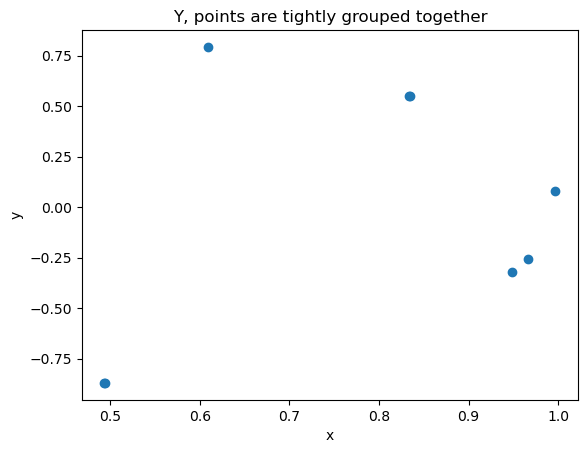

toy_problems/02_simple_four_and_four.tp gamma: 0.051 normalized mutual information score: 1.0 


labels to be checked:
[0 0 0 0 1 1 1 1] 

labels returned:
[0 0 0 0 1 1 1 1] 



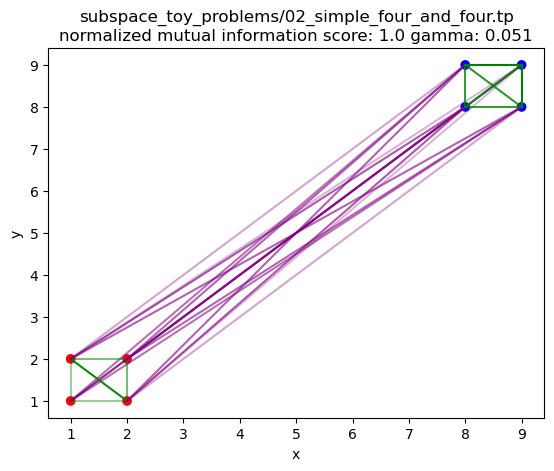

In [6]:
set_K = 0
gamma = 0.051
printer = True
plotter = True
save_figure = True
subspace_clustering('toy_problems/02_simple_four_and_four.tp',
                    'toy_problems/02_simple_four_and_four_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [7]:
set_K = 0
gamma = np.linspace(0.001,0.1,50)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/04_two_horizontal_lines_0_to_1.tp',
                        'toy_problems/03_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.001 normalized mutual information score: 0.174 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.003 normalized mutual information score: 0.505 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.005 normalized mutual information score: 0.051 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.007 normalized mutual information score: 0.243 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.009 normalized mutual information score: 0.185 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.011 normalized mutual information score: 0.187 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.013 normalized mutual information score: 0.206 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.015 normalized mutual information score: 0.705 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.017 normalized mutual information score: 0.424 

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0

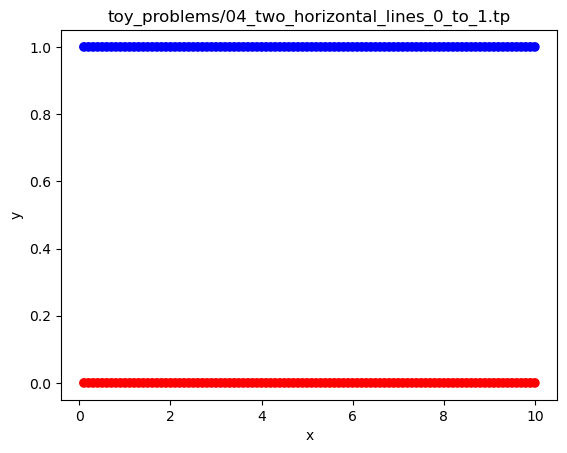

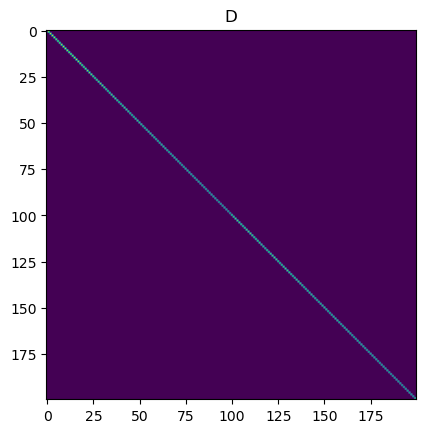

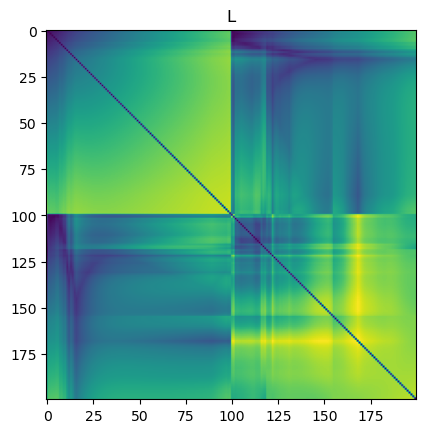

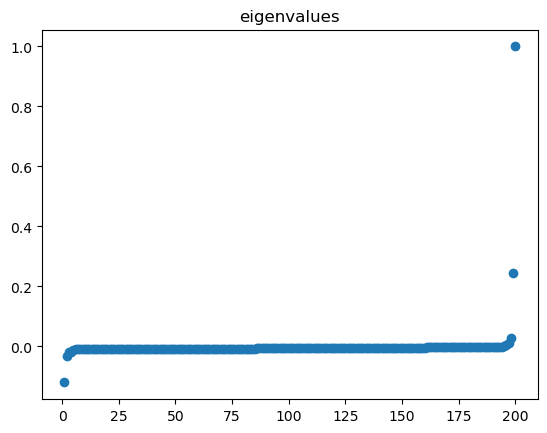

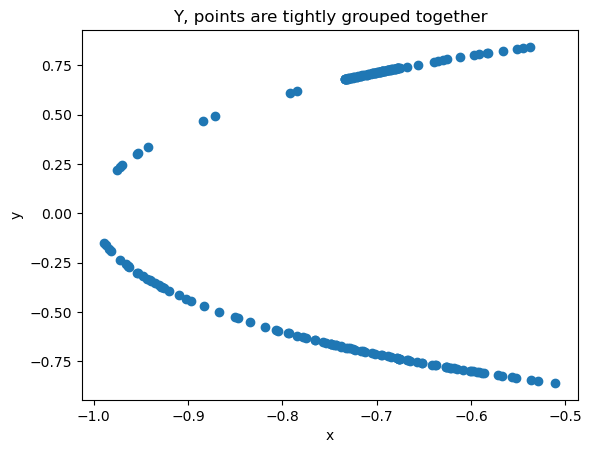

toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.033 normalized mutual information score: 1.0 



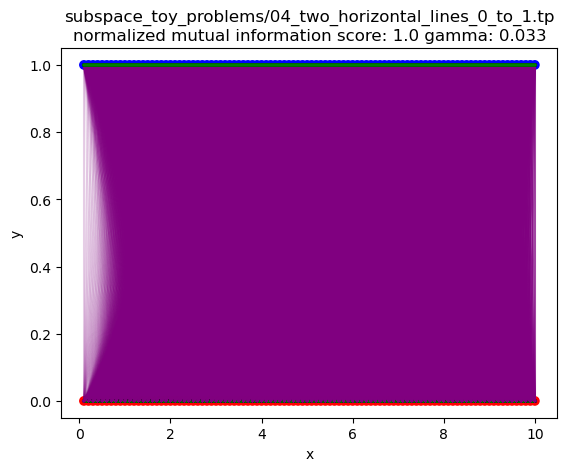

In [8]:
set_K = 0
gamma = 0.033
printer = False
plotter = True
save_figure = True
subspace_clustering('toy_problems/04_two_horizontal_lines_0_to_1.tp',
                    'toy_problems/03_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [9]:
set_K = 0
gamma = np.linspace(0.001,1,50)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/05_two_horizontal_lines_0_to_4.tp',
                        'toy_problems/03_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.001 normalized mutual information score: 0.674 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.021 normalized mutual information score: 0.253 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.042 normalized mutual information score: 1.0 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.062 normalized mutual information score: 0.902 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.083 normalized mutual information score: 0.902 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.103 normalized mutual information score: 0.856 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.123 normalized mutual information score: 0.96 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.144 normalized mutual information score: 1.0 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.164 normalized mutual information score: 1.0 

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.184 no

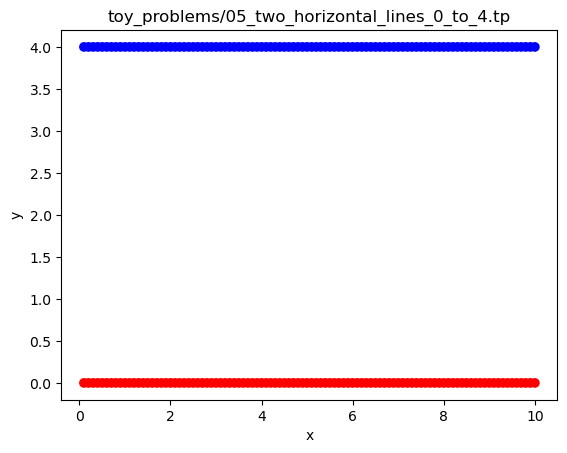

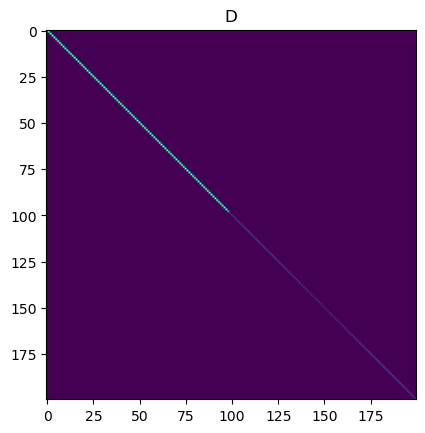

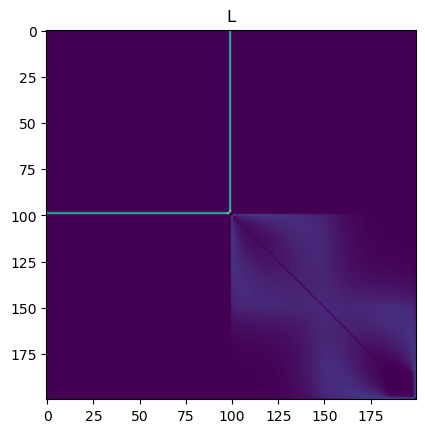

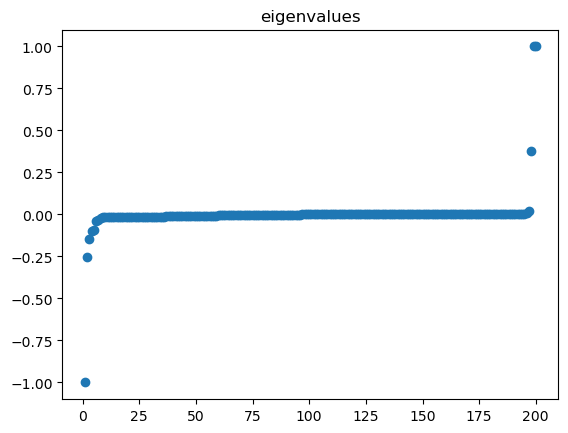

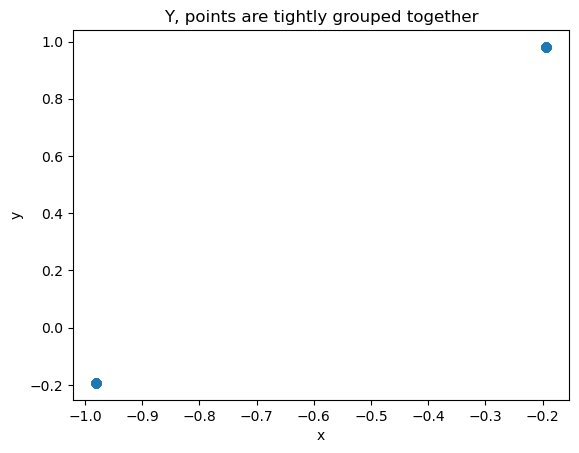

toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.5 normalized mutual information score: 1.0 



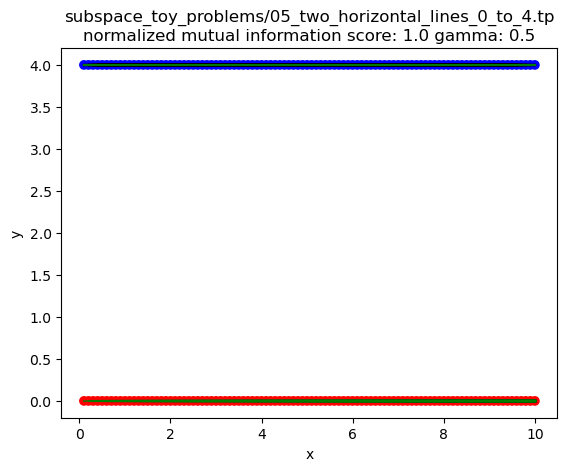

In [10]:
set_K = 0
gamma = 0.5
printer = False
plotter = True
save_figure = True
subspace_clustering('toy_problems/05_two_horizontal_lines_0_to_4.tp',
                    'toy_problems/03_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [11]:
set_K = 0
gamma = np.linspace(0.001,1,50)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/06_two_horizontal_lines_0_to_5.tp',
                        'toy_problems/03_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.001 normalized mutual information score: 0.729 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.021 normalized mutual information score: 0.297 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.042 normalized mutual information score: 1.0 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.062 normalized mutual information score: 1.0 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.083 normalized mutual information score: 0.929 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.103 normalized mutual information score: 1.0 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.123 normalized mutual information score: 1.0 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.144 normalized mutual information score: 0.96 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.164 normalized mutual information score: 1.0 

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.184 normal

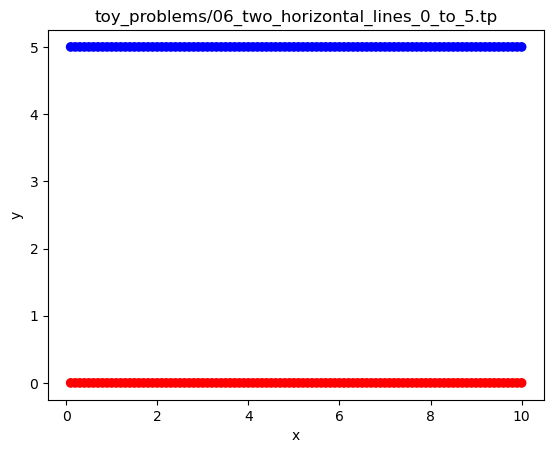

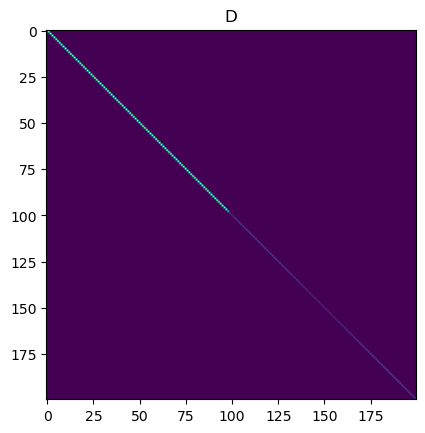

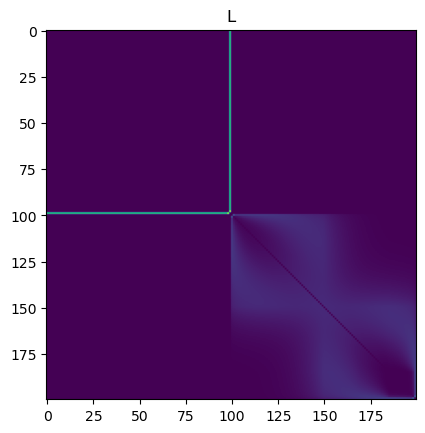

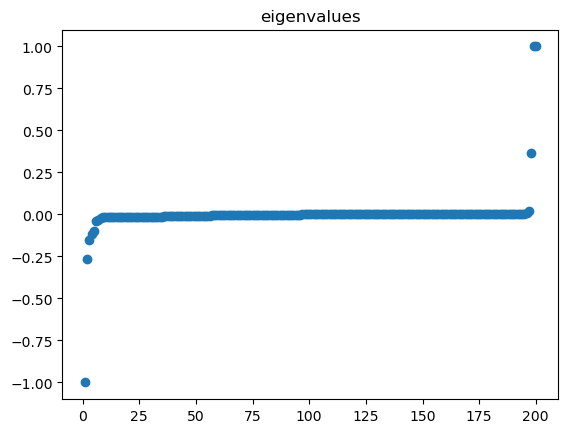

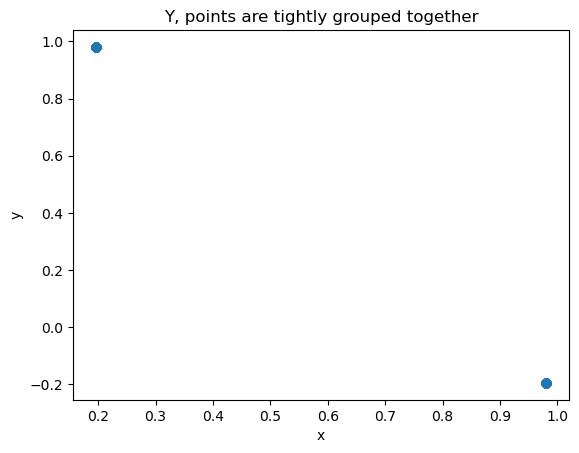

toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.5 normalized mutual information score: 1.0 



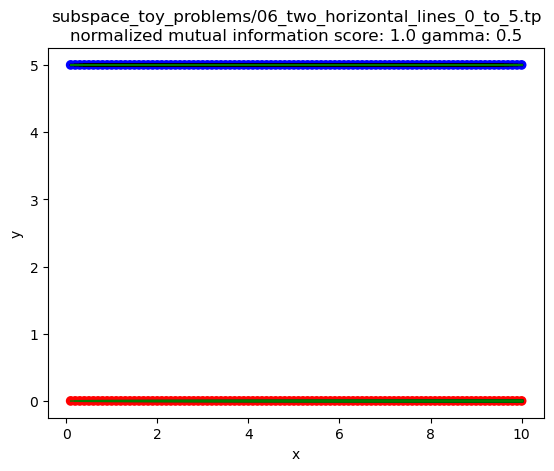

In [12]:
set_K = 0
gamma = 0.5
plotter = True
printer = False
norm_sub = False
extra_plotter = True
subspace_clustering('toy_problems/06_two_horizontal_lines_0_to_5.tp',
                    'toy_problems/03_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [13]:
set_K = 0
gamma = np.linspace(.001,.5,50)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/07_two_interlocking_circles.tp',
                        'toy_problems/03_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

toy_problems/07_two_interlocking_circles.tp gamma: 0.001 normalized mutual information score: 0.0 

toy_problems/07_two_interlocking_circles.tp gamma: 0.011 normalized mutual information score: 0.031 

toy_problems/07_two_interlocking_circles.tp gamma: 0.021 normalized mutual information score: 0.056 

toy_problems/07_two_interlocking_circles.tp gamma: 0.032 normalized mutual information score: 0.0 

toy_problems/07_two_interlocking_circles.tp gamma: 0.042 normalized mutual information score: 0.002 

toy_problems/07_two_interlocking_circles.tp gamma: 0.052 normalized mutual information score: 0.0 

toy_problems/07_two_interlocking_circles.tp gamma: 0.062 normalized mutual information score: 0.0 

toy_problems/07_two_interlocking_circles.tp gamma: 0.072 normalized mutual information score: 0.001 

toy_problems/07_two_interlocking_circles.tp gamma: 0.082 normalized mutual information score: 0.0 

toy_problems/07_two_interlocking_circles.tp gamma: 0.093 normalized mutual information score

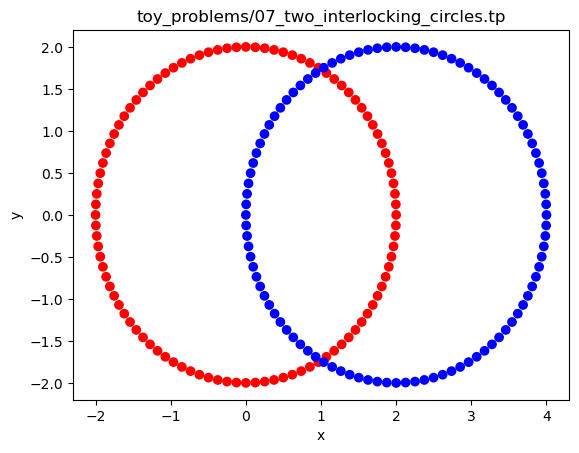

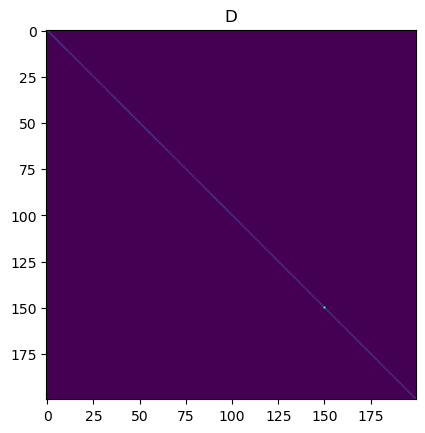

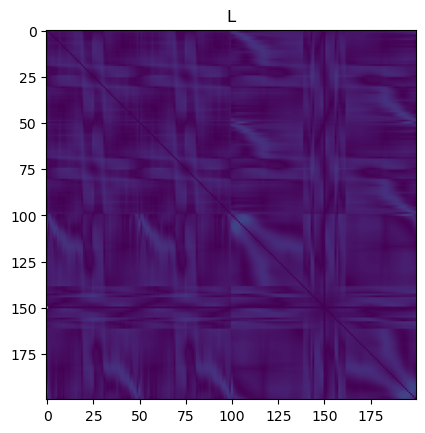

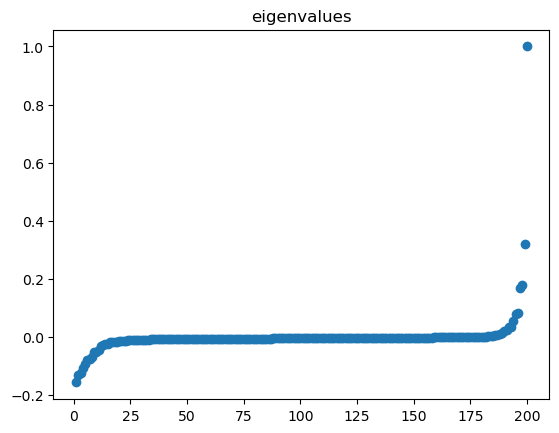

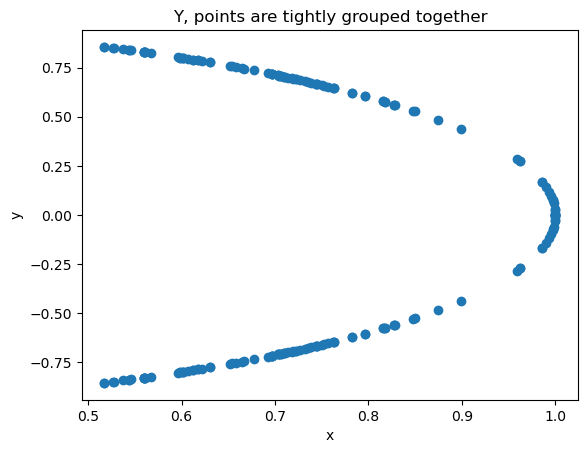

toy_problems/07_two_interlocking_circles.tp gamma: 0.235 normalized mutual information score: 0.0 



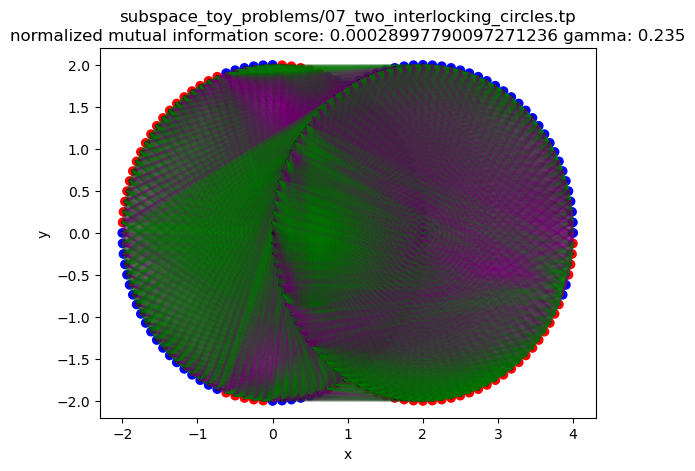

In [15]:
set_K = 0
gamma = 0.235
printer = False
plotter = True
save_figure = True
subspace_clustering('toy_problems/07_two_interlocking_circles.tp',
                    'toy_problems/03_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [16]:
set_K = 0
gamma = np.linspace(.001,1,50)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/08_two_interlocking_curves.tp',
                        'toy_problems/03_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

toy_problems/08_two_interlocking_curves.tp gamma: 0.001 normalized mutual information score: 0.0 

toy_problems/08_two_interlocking_curves.tp gamma: 0.021 normalized mutual information score: 0.002 

toy_problems/08_two_interlocking_curves.tp gamma: 0.042 normalized mutual information score: 0.21 

toy_problems/08_two_interlocking_curves.tp gamma: 0.062 normalized mutual information score: 0.0 

toy_problems/08_two_interlocking_curves.tp gamma: 0.083 normalized mutual information score: 0.0 

toy_problems/08_two_interlocking_curves.tp gamma: 0.103 normalized mutual information score: 0.0 

toy_problems/08_two_interlocking_curves.tp gamma: 0.123 normalized mutual information score: 0.0 

toy_problems/08_two_interlocking_curves.tp gamma: 0.144 normalized mutual information score: 0.0 

toy_problems/08_two_interlocking_curves.tp gamma: 0.164 normalized mutual information score: 0.0 

toy_problems/08_two_interlocking_curves.tp gamma: 0.184 normalized mutual information score: 0.001 

toy_p

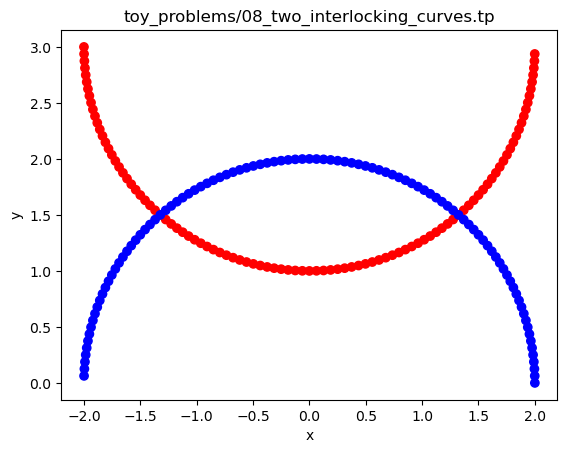

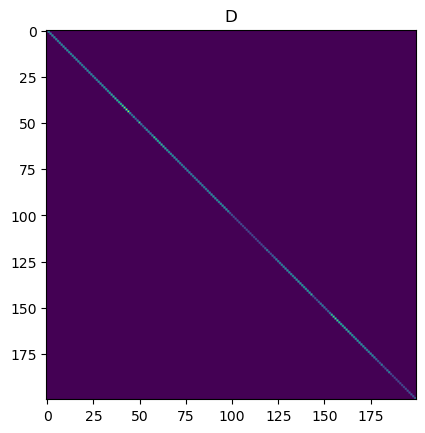

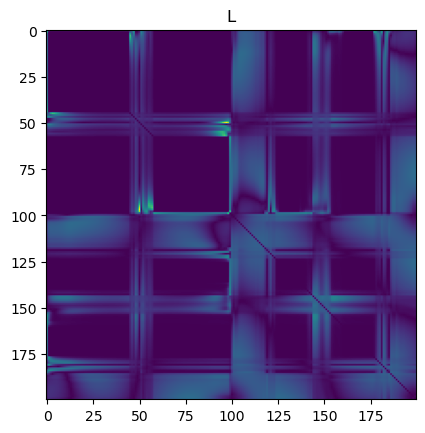

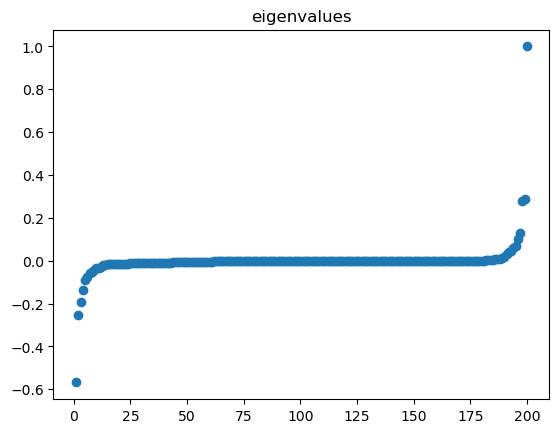

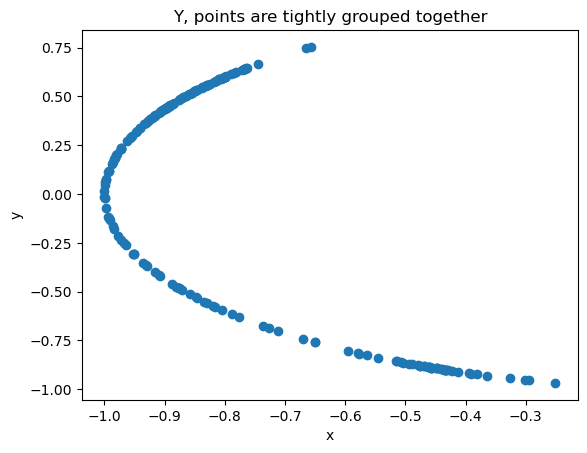

toy_problems/08_two_interlocking_curves.tp gamma: 0.286 normalized mutual information score: 0.017 



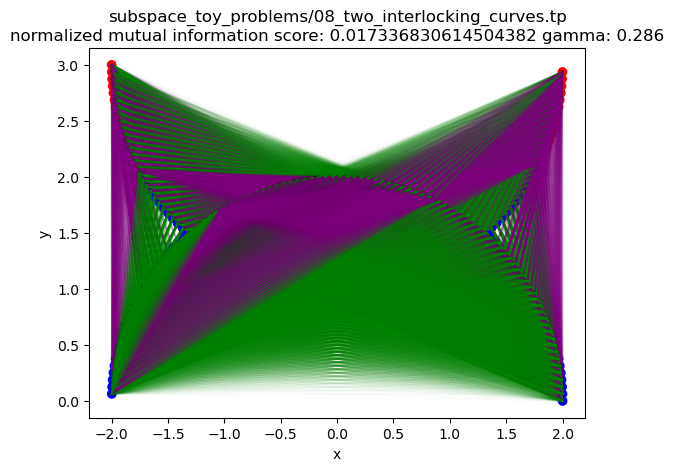

In [17]:
set_K = 0
gamma = 0.286
printer = False
plotter = True
save_figure = True
subspace_clustering('toy_problems/08_two_interlocking_curves.tp',
                    'toy_problems/03_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [18]:
set_K = 0
gamma = np.linspace(.5,10,50)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/09_two_subset_circles.tp',
                        'toy_problems/03_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

toy_problems/09_two_subset_circles.tp gamma: 0.5 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 0.694 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 0.888 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 1.082 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 1.276 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 1.469 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 1.663 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 1.857 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 2.051 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 2.245 normalized mutual information score: 0.0 

toy_problems/09_two_subset_circles.tp gamma: 2.439 normalized 

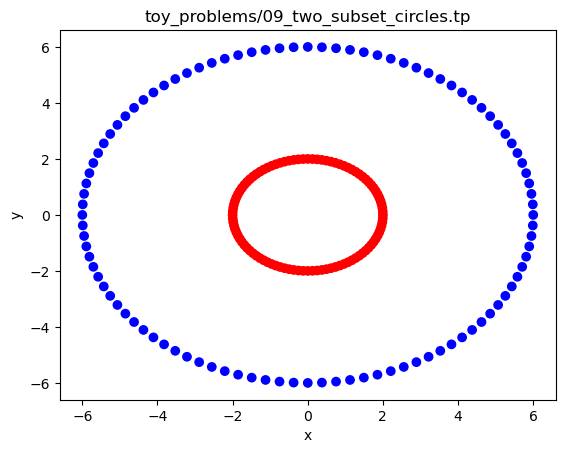

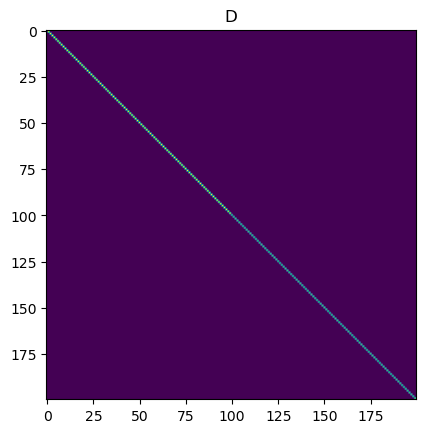

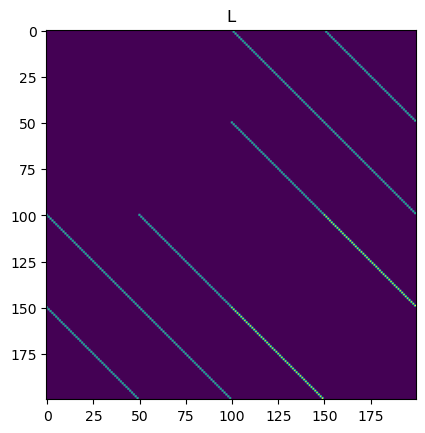

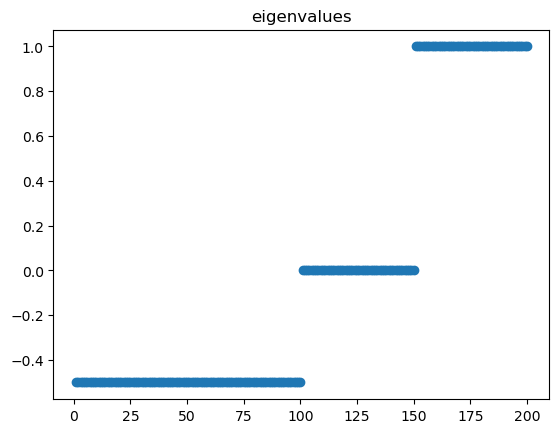

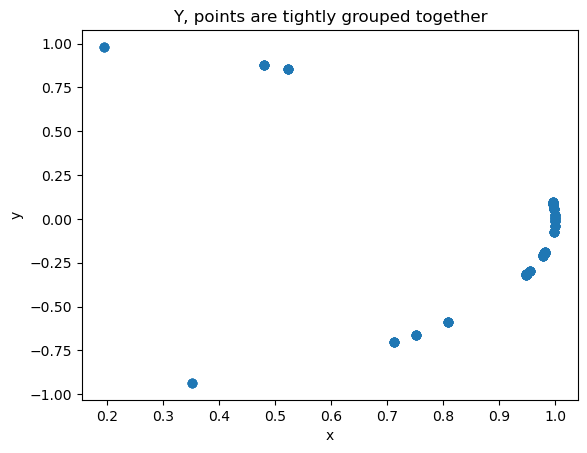

toy_problems/09_two_subset_circles.tp gamma: 0.5 normalized mutual information score: 0.0 



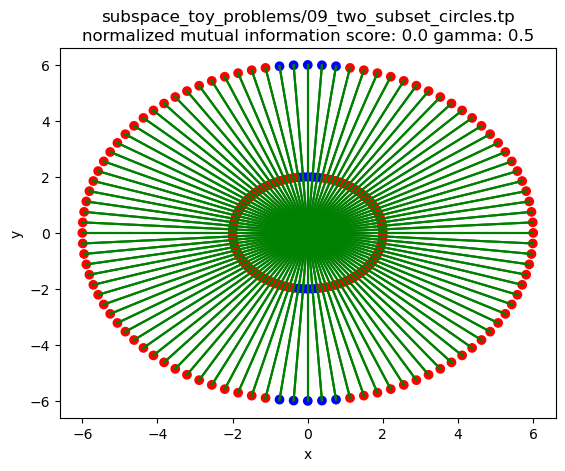

In [19]:
set_K = 0
gamma = 0.5
printer = False
plotter = True
save_figure = True
subspace_clustering('toy_problems/09_two_subset_circles.tp',
                    'toy_problems/03_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [20]:
set_K = 0
gamma = np.linspace(.001,.1,2)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/10_x.tp',
                        'toy_problems/03_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

toy_problems/10_x.tp gamma: 0.001 normalized mutual information score: 0.96 

toy_problems/10_x.tp gamma: 0.1 normalized mutual information score: 0.96 



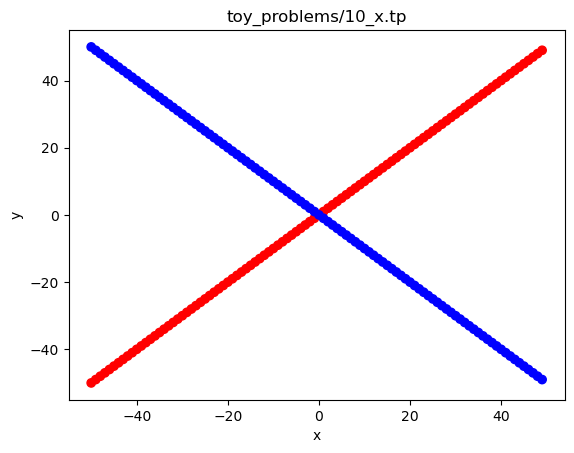

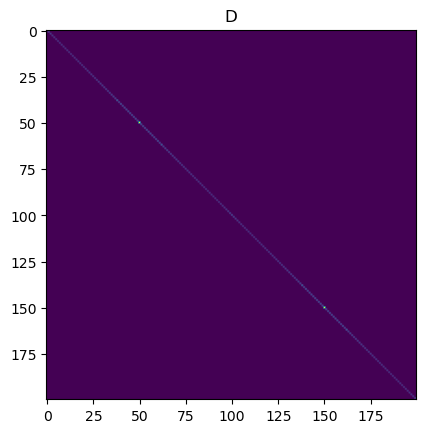

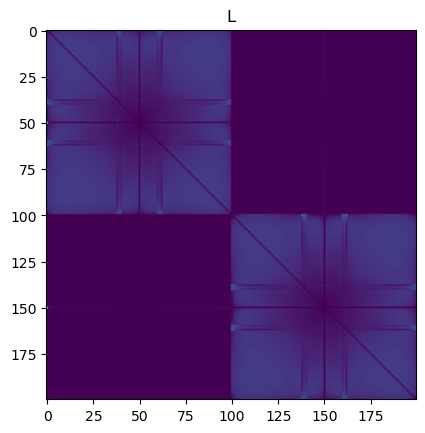

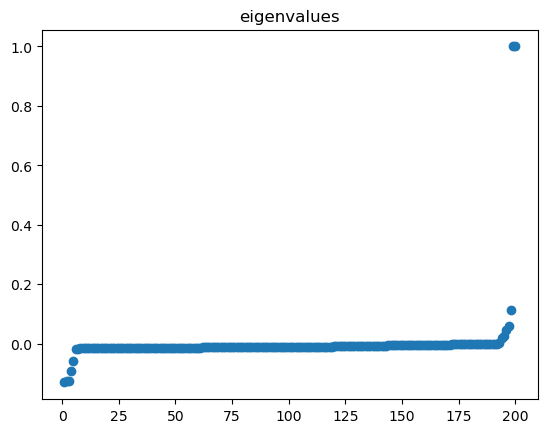

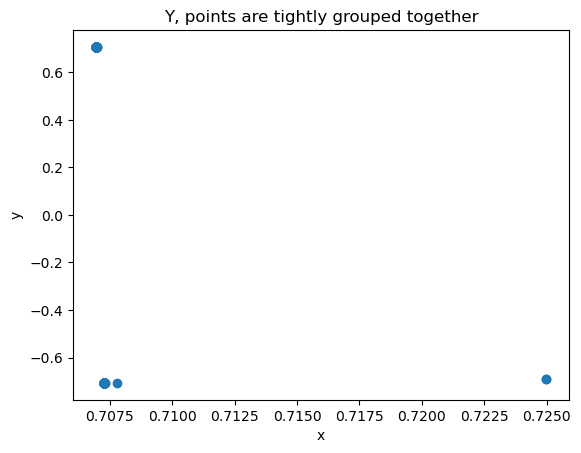

toy_problems/10_x.tp gamma: 0.01 normalized mutual information score: 0.96 



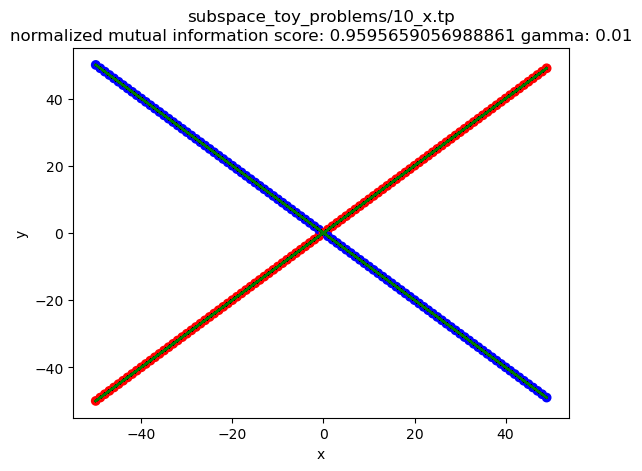

In [22]:
set_K = 0
gamma = 0.01
printer = False
plotter = True
save_figure = True
subspace_clustering('toy_problems/10_x.tp',
                    'toy_problems/03_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

In [23]:
set_K = 0
gamma = np.linspace(.1,1,20)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds',
                        'datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1_ground_truth.ds',
                        i, set_K, printer, plotter, save_figure)

datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.1 normalized mutual information score: 0.045 

datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.147 normalized mutual information score: 0.768 

datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.195 normalized mutual information score: 0.914 

datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.242 normalized mutual information score: 0.914 

datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.289 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.337 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.384 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.432 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/02_binary_alp

In [24]:
set_K = 0
gamma = np.linspace(.1,1,20)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds',
                        'datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8_ground_truth.ds',
                        i, set_K, printer, plotter, save_figure)

datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.1 normalized mutual information score: 0.045 

datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.147 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.195 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.242 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.289 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.337 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.384 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.432 normalized mutual information score: 1.0 

datasets/binary_alpha_digits/03_binary_alpha_dig

In [25]:
set_K = 0
gamma = np.linspace(1,10,20)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('datasets/binary_alpha_digits/01_binary_alpha_digits.ds',
                        'datasets/binary_alpha_digits/01_binary_alpha_digits_ground_truth.ds',
                        i, set_K, printer, plotter, save_figure)

SolverError: Solver 'ECOS' failed. Try another solver, or solve with verbose=True for more information.

In [ ]:
### don't run this cell ###

set_K = 0
gamma = np.linspace(0.001,1,50)
plotter = False
printer = False
save_figure = False
for i in gamma:
    subspace_clustering('toy_problems/02_simple_four_and_four.tp',
                        'toy_problems/02_simple_four_and_four_ground_truth.tp',
                        i, set_K, printer, plotter, save_figure)

set_K = 0
gamma = 0.0585
printer = True
plotter = True
save_figure = True
subspace_clustering('toy_problems/01_simple_two_and_two.tp',
                    'toy_problems/01_simple_two_and_two_ground_truth.tp',
                    gamma, set_K, printer, plotter, save_figure)

printer = False
plotter = True
save_figure = True